<a href="https://colab.research.google.com/github/19mddill/Deep_Learning_Notebooks/blob/main/ANN_keras.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)","petal width (cm)"]].values
y = (iris.target == 0)

per_clf = Perceptron(random_state=42)
per_clf.fit(X,y)


Perceptron(random_state=42)

In [ ]:
X_new = [[2,.5],[3,1]]
y_pred = per_clf.predict(X_new)
y_pred

array([ True, False])

w1: 5.800, w2: -16.700, b: -7.000
n_iter_ (iterations actually run): 9
Training accuracy: 0.653
Misclassified points: 52 out of 150

Saved plot.


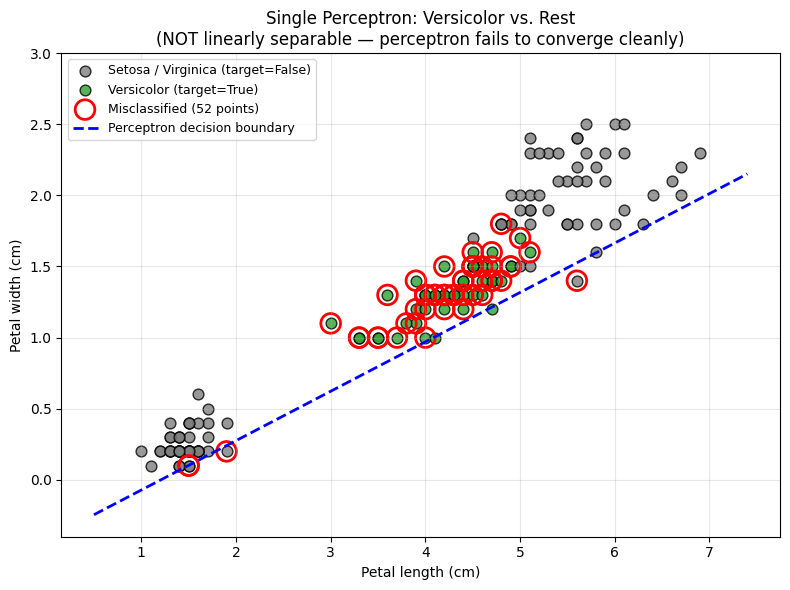

In [ ]:
iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 1)   # Versicolor vs rest

per_clf = Perceptron(random_state=42, max_iter=1000)
per_clf.fit(X, y)

w1, w2 = per_clf.coef_[0]
b = per_clf.intercept_[0]

print(f"w1: {w1:.3f}, w2: {w2:.3f}, b: {b:.3f}")
print(f"n_iter_ (iterations actually run): {per_clf.n_iter_}")

preds = per_clf.predict(X)
n_errors = np.sum(preds != y)
print(f"Training accuracy: {(preds == y).mean():.3f}")
print(f"Misclassified points: {n_errors} out of {len(y)}")

x1_range = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
x2_boundary = -(w1 * x1_range + b) / w2

plt.figure(figsize=(8, 6))

for i, name in enumerate(iris.target_names):
    mask = (iris.target == i)
    color = '#2ca02c' if i == 1 else '#7f7f7f'
    label = 'Versicolor (target=True)' if i == 1 else ('Setosa / Virginica (target=False)' if i == 0 else None)
    plt.scatter(X[mask, 0], X[mask, 1], c=color, label=label, edgecolor='k', s=60, alpha=0.8)

misclassified = preds != y
plt.scatter(X[misclassified, 0], X[misclassified, 1], facecolors='none',
            edgecolors='red', s=200, linewidths=2, label=f'Misclassified ({n_errors} points)')

plt.plot(x1_range, x2_boundary, 'b--', linewidth=2, label='Perceptron decision boundary')

plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Single Perceptron: Versicolor vs. Rest\n(NOT linearly separable — perceptron fails to converge cleanly)')
plt.legend(loc='upper left', fontsize=9)
plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
plt.grid(alpha=0.3)
plt.tight_layout()
print("\nSaved plot.")

w1 (petal length weight): -1.400
w2 (petal width weight):  -2.200
b (bias):                 4.000

Saved plot.


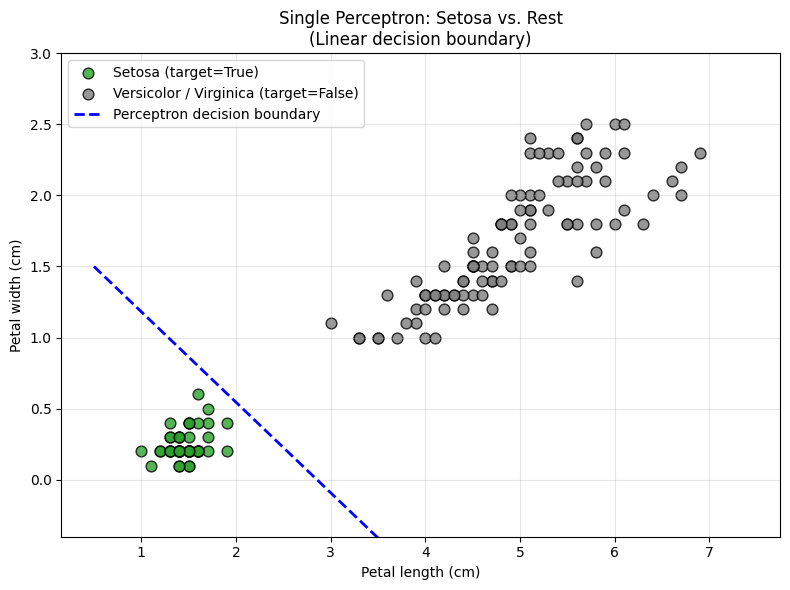

In [ ]:


iris = load_iris(as_frame=True)
X = iris.data[["petal length (cm)", "petal width (cm)"]].values
y = (iris.target == 0)

per_clf = Perceptron(random_state=42)
per_clf.fit(X, y)


w1, w2 = per_clf.coef_[0]
b = per_clf.intercept_[0]

print(f"w1 (petal length weight): {w1:.3f}")
print(f"w2 (petal width weight):  {w2:.3f}")
print(f"b (bias):                 {b:.3f}")


x1_range = np.linspace(X[:, 0].min() - 0.5, X[:, 0].max() + 0.5, 200)
x2_boundary = -(w1 * x1_range + b) / w2

plt.figure(figsize=(8, 6))


colors = ['#2ca02c', '#7f7f7f', '#7f7f7f']  # Setosa green, other two grey
labels = ['Setosa (target)', 'Versicolor/Virginica', None]

for i, name in enumerate(iris.target_names):
    mask = (iris.target == i)
    color = colors[i]
    label = 'Setosa (target=True)' if i == 0 else ('Versicolor / Virginica (target=False)' if i == 1 else None)
    plt.scatter(X[mask, 0], X[mask, 1], c=color, label=label, edgecolor='k', s=60, alpha=0.8)


plt.plot(x1_range, x2_boundary, 'b--', linewidth=2, label='Perceptron decision boundary')

plt.xlabel('Petal length (cm)')
plt.ylabel('Petal width (cm)')
plt.title('Single Perceptron: Setosa vs. Rest\n(Linear decision boundary)')
plt.legend(loc='upper left')
plt.ylim(X[:, 1].min() - 0.5, X[:, 1].max() + 0.5)
plt.grid(alpha=0.3)
plt.tight_layout()
print("\nSaved plot.")


In [ ]:
housing = fetch_california_housing()
housing
X_train_full,X_test,y_train_full,y_test = train_test_split(housing.data,housing.target,random_state=42)
X_train,X_valid,y_train,y_valid = train_test_split(X_train_full,y_train_full,random_state=42)
housing.DESCR

'.. _california_housing_dataset:\n\nCalifornia Housing dataset\n--------------------------\n\n**Data Set Characteristics:**\n\n:Number of Instances: 20640\n\n:Number of Attributes: 8 numeric, predictive attributes and the target\n\n:Attribute Information:\n    - MedInc        median income in block group\n    - HouseAge      median house age in block group\n    - AveRooms      average number of rooms per household\n    - AveBedrms     average number of bedrooms per household\n    - Population    block group population\n    - AveOccup      average number of household members\n    - Latitude      block group latitude\n    - Longitude     block group longitude\n\n:Missing Attribute Values: None\n\nThis dataset was obtained from the StatLib repository.\nhttps://www.dcc.fc.up.pt/~ltorgo/Regression/cal_housing.html\n\nThe target variable is the median house value for California districts,\nexpressed in hundreds of thousands of dollars ($100,000).\n\nThis dataset was derived from the 1990 U.S

In [ ]:
mlp_reg = MLPRegressor(hidden_layer_sizes=[50,50,50],random_state=42)

In [ ]:
pipeline = make_pipeline(StandardScaler(),mlp_reg)
pipeline.fit(X_train,y_train)
y_pred = pipeline.predict(X_valid)
rmse = root_mean_squared_error(y_valid, y_pred)
rmse

0.5053326657968684

## Iris


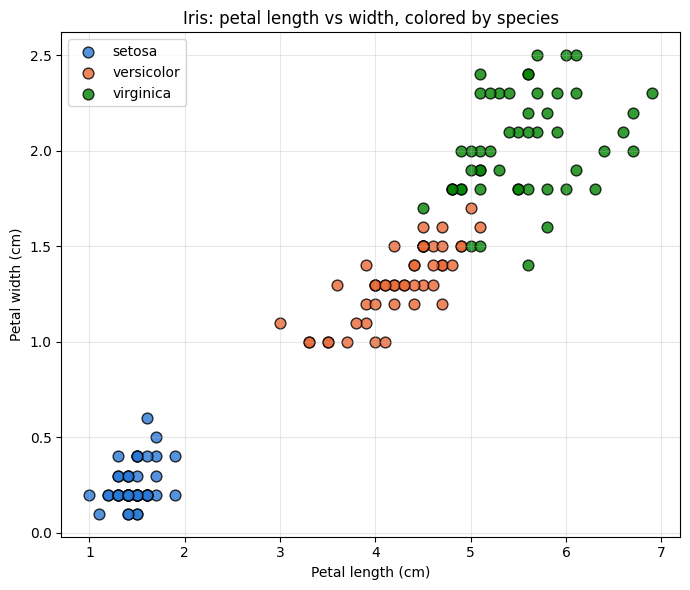

In [5]:

iris = load_iris()
X = iris.data[:, [2, 3]]  # petal length, petal width
y = iris.target

colors = ['#2a78d6', '#eb6834', '#008300']
labels = iris.target_names

plt.figure(figsize=(7, 6))
for i, label in enumerate(labels):
    mask = y == i
    plt.scatter(X[mask, 0], X[mask, 1], c=colors[i], label=label, s=60, edgecolors='k', alpha=0.8)

plt.xlabel("Petal length (cm)")
plt.ylabel("Petal width (cm)")
plt.title("Iris: petal length vs width, colored by species")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Keras


In [29]:
import numpy as np
from sklearn.datasets import load_iris
from sklearn.linear_model import Perceptron
import matplotlib.pyplot as plt

from sklearn.datasets import fetch_california_housing
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import root_mean_squared_error
from sklearn.datasets import load_iris
import tensorflow as tf

In [30]:
fashion_mnist = tf.keras.datasets.fashion_mnist.load_data()

In [31]:
(X_train_full, y_train_full), (X_test, y_test) = fashion_mnist

In [32]:
X_train, y_train = X_train_full[:-5000], y_train_full[:-5000]
X_valid, y_valid = X_train_full[-5000:], y_train_full[-5000:]

In [33]:
X_train.shape, X_train.dtype

((55000, 28, 28), dtype('uint8'))

In [34]:
X_train[0]

array([[  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,
          0,   0,  13,  73,   0,   0,   1,   4,   0,   0,   0,   0,   1,
          1,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   3,
          0,  36, 136, 127,  62,  54,   0,   0,   0,   1,   3,   4,   0,
          0,   3],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,
          0, 102, 204, 176, 134, 144, 123,  23,   0,   0,   0,   0,  12,
         10,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
          0, 155, 236, 207, 178, 107, 156, 161, 109,  64,  23,  77, 130,
         72,  15],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   0,
         69, 207, 223, 218, 216, 216, 163, 127, 121, 122, 146, 141,  88,
        172,  66],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   1,   1,   0,
        200, 232, 232, 233, 229, 223, 223, 215, 213, 164, 127, 123, 196,
        229,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        183, 225, 216, 223, 228, 235, 227, 224, 222, 224, 221, 223, 245,
        173,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   0,
        193, 228, 218, 213, 198, 180, 212, 210, 211, 213, 223, 220, 243,
        202,   0],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   1,   3,   0,  12,
        219, 220, 212, 218, 192, 169, 227, 208, 218, 224, 212, 226, 197,
        209,  52],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   0,   6,   0,  99,
        244, 222, 220, 218, 203, 198, 221, 215, 213, 222, 220, 245, 119,
        167,  56],
       [  0,   0,   0,   0,   0,   0,   0,   0,   0,   4,   0,   0,  55,
        236, 228, 230, 228, 240, 232, 213, 218, 223, 234, 217, 217, 209,
         92,   0],
       [  0,   0,   1,   4,   6,   7,   2,   0,   0,   0,   0,   0, 237,
        226, 217, 223, 222, 219, 222, 221, 216, 223, 229, 215, 218, 255,
         77,   0],
       [  0,   3,   0,   0,   0,   0,   0,   0,   0,  62, 145, 204, 228,
        207, 213, 221, 218, 208, 211, 218, 224, 223, 219, 215, 224, 244,
        159,   0],
       [  0,   0,   0,   0,  18,  44,  82, 107, 189, 228, 220, 222, 217,
        226, 200, 205, 211, 230, 224, 234, 176, 188, 250, 248, 233, 238,
        215,   0],
       [  0,  57, 187, 208, 224, 221, 224, 208, 204, 214, 208, 209, 200,
        159, 245, 193, 206, 223, 255, 255, 221, 234, 221, 211, 220, 232,
        246,   0],
       [  3, 202, 228, 224, 221, 211, 211, 214, 205, 205, 205, 220, 240,
         80, 150, 255, 229, 221, 188, 154, 191, 210, 204, 209, 222, 228,
        225,   0],
       [ 98, 233, 198, 210, 222, 229, 229, 234, 249, 220, 194, 215, 217,
        241,  65,  73, 106, 117, 168, 219, 221, 215, 217, 223, 223, 224,
        229,  29],
       [ 75, 204, 212, 204, 193, 205, 211, 225, 216, 185, 197, 206, 198,
        213, 240, 195, 227, 245, 239, 223, 218, 212, 209, 222, 220, 221,
        230,  67],
       [ 48, 203, 183, 194, 213, 197, 185, 190, 194, 192, 202, 214, 219,
        221, 220, 236, 225, 216, 199, 206, 186, 181, 177, 172, 181, 205,
        206, 115],
       [  0, 122, 219, 193, 179, 171, 183, 196, 204, 210, 213, 207, 211,
        210, 200, 196, 194, 191, 195, 191, 198, 192, 176, 156, 167, 177,
        210,  92],
       [  0,   0,  74, 189, 212, 191, 175, 172, 175, 181, 185, 188, 189,
        188, 193, 198, 204, 209, 210, 210, 211, 188, 188, 194, 192, 216,
        170,   0],
       [  2,   0,   0,   0,  66, 200, 22

In [35]:
X_train, X_valid, X_test = X_train / 255., X_valid / 255., X_test / 255.

In [36]:
X_train[0]

array([[0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        ],
       [0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.        , 0.        , 0.        , 0.        ,
        0.        , 0.    

In [37]:
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
               "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

In [38]:
class_names[y_train[0]]

'Ankle boot'

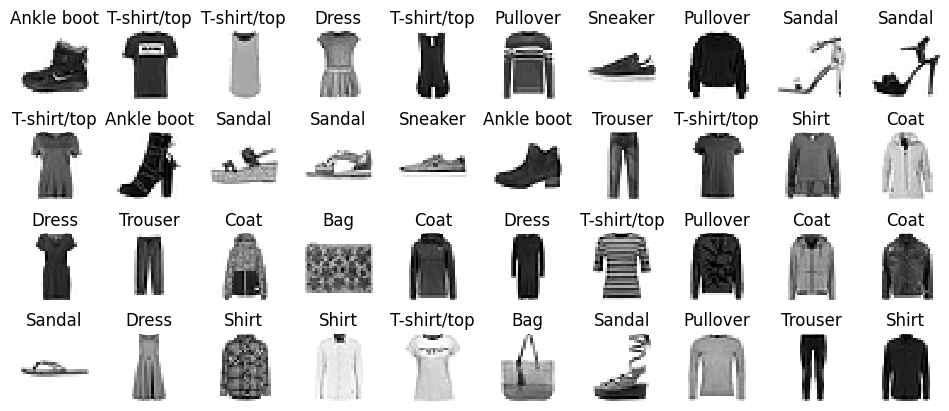

In [39]:
n_rows = 4
n_cols = 10
plt.figure(figsize=(n_cols * 1.2, n_rows * 1.2))
for row in range(n_rows):
    for col in range(n_cols):
        index = n_cols * row + col
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(X_train[index], cmap="binary", interpolation="nearest")
        plt.axis('off')
        plt.title(class_names[y_train[index]])
plt.subplots_adjust(wspace=0.2, hspace=0.5)
plt.show()

In [41]:
# tf.random.set_seed(42)
# model = tf.keras.Sequential()
# model.add(tf.keras.layers.Flatten(input_shape=[28, 28]))
# model.add(tf.keras.layers.Flatten())
# model.add(tf.keras.layers.Dense(300, activation="relu"))
# model.add(tf.keras.layers.Dense(100, activation="relu"))
# model.add(tf.keras.layers.Dense(10, activation="softmax"))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [42]:
tf.random.set_seed(42)
model = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=[28, 28]),
    tf.keras.layers.Dense(300, activation="relu"),
    tf.keras.layers.Dense(100, activation="relu"),
    tf.keras.layers.Dense(10, activation="softmax")
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [43]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten_2 (Flatten)             │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 300)            │       235,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 100)            │        30,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 266,610 (1.02 MB)

 Trainable params: 266,610 (1.02 MB)

 Non-trainable params: 0 (0.00 B)

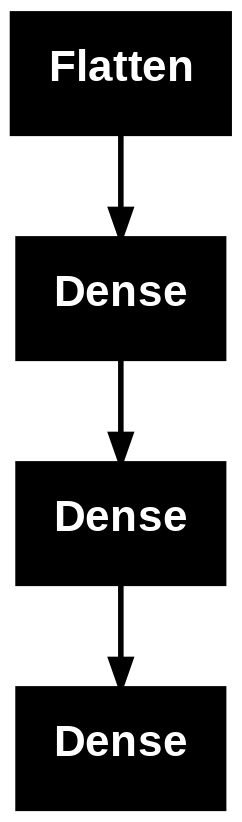

In [45]:
tf.keras.utils.plot_model(model)

In [46]:
model.layers

[<Flatten name=flatten_2, built=True>,
 <Dense name=dense_3, built=True>,
 <Dense name=dense_4, built=True>,
 <Dense name=dense_5, built=True>]